# Modeling & Hyperparameter Tuning
**Proyek:** Pothole Detection System

Notebook ini mencakup:
1. Setup & Device Detection
2. Baseline Model
3. Model Definition (EfficientNet-B0, ResNet18, MobileNetV3, ViT-Tiny)
4. Training Loop dengan Early Stopping
5. Hyperparameter Tuning (6 eksperimen)
6. Perbandingan Hasil

---
## Setup & Device Detection

In [2]:
import os
import json
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import timm
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Paths
ROOT      = Path("../").resolve()
PROC_DIR  = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASSES    = ["normal", "potholes"]
NUM_CLASSES = 2
BATCH_SIZE  = 32

Device  : cuda
GPU     : NVIDIA GeForce RTX 5060 Ti
VRAM    : 17.1 GB


---
## DataLoader

In [3]:
# Transform
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(PROC_DIR / "train", transform=transform_train)
val_ds   = datasets.ImageFolder(PROC_DIR / "val",   transform=transform_val)
test_ds  = datasets.ImageFolder(PROC_DIR / "test",  transform=transform_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds)} gambar")
print(f"Val   : {len(val_ds)} gambar")
print(f"Test  : {len(test_ds)} gambar")
print(f"Class mapping: {train_ds.class_to_idx}")

# Class weights untuk imbalance
class_counts = np.array([len(list((PROC_DIR / "train" / c).glob("*.jpg"))) for c in CLASSES])
class_weights = torch.tensor(len(train_ds) / (NUM_CLASSES * class_counts), dtype=torch.float).to(DEVICE)
print(f"Class weights: {class_weights}")

Train : 476 gambar
Val   : 102 gambar
Test  : 103 gambar
Class mapping: {'normal': 0, 'potholes': 1}
Class weights: tensor([0.9675, 1.0348], device='cuda:0')


---
## Baseline Model

In [4]:
# Baseline: majority class
train_labels = [label for _, label in train_ds.samples]
majority_class = max(set(train_labels), key=train_labels.count)

val_labels = [label for _, label in val_ds.samples]
baseline_preds = [majority_class] * len(val_labels)

baseline_acc = accuracy_score(val_labels, baseline_preds)
baseline_f1  = f1_score(val_labels, baseline_preds, average="macro", zero_division=0)

print(f"Majority class : {CLASSES[majority_class]}")
print(f"Baseline Accuracy (val) : {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")
print(f"Baseline F1-macro (val) : {baseline_f1:.4f}")
print("\nSemua model WAJIB melampaui baseline ini.")

Majority class : normal
Baseline Accuracy (val) : 0.5196 (52.0%)
Baseline F1-macro (val) : 0.3419

Semua model WAJIB melampaui baseline ini.


---
## Model Definition

In [5]:
def build_model(name: str, freeze_backbone: bool = False) -> nn.Module:
    """Bangun model transfer learning dengan classifier head baru."""
    if name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    elif name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        if freeze_backbone:
            for name_, param in model.named_parameters():
                if "fc" not in name_:
                    param.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    elif name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)

    elif name == "vit_tiny":
        # ViT-Tiny
        model = timm.create_model(
            "vit_tiny_patch16_224.augreg_in21k_ft_in1k",
            pretrained=True,
            num_classes=NUM_CLASSES
        )
        if freeze_backbone:
            for name_, param in model.named_parameters():
                if "head" not in name_:
                    param.requires_grad = False

    else:
        raise ValueError(f"Model '{name}' tidak dikenali.")

    return model.to(DEVICE)


# Hitung jumlah parameter
for mname in ["efficientnet_b0", "resnet18", "mobilenet_v3_small", "vit_tiny"]:
    m = build_model(mname)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{mname:<22}: {params:>10,} trainable params")
    del m
torch.cuda.empty_cache()

efficientnet_b0       :  4,010,110 trainable params
resnet18              : 11,177,538 trainable params
mobilenet_v3_small    :  1,519,906 trainable params


vit_tiny              :  5,524,802 trainable params


---
## Training Loop

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc      = correct / total
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    prec     = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    rec      = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    # recall per kelas
    rec_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
    rec_potholes  = rec_per_class[1] if len(rec_per_class) > 1 else 0.0

    # Composite score
    composite = 0.4 * f1 + 0.6 * rec_potholes

    return total_loss / total, acc, f1, prec, rec, rec_potholes, composite


def run_experiment(exp_name, model_name, lr, freeze, n_epochs, use_scheduler=False, patience=5):
    print(f"\n{'='*70}")
    print(f"  {exp_name}: {model_name} | lr={lr} | freeze={freeze} | epochs={n_epochs}")
    print(f"{'='*70}")
    print(f"  {'Ep':>3} | {'tr_loss':>8} {'tr_acc':>7} | {'vl_loss':>8} {'vl_acc':>7} "
          f"{'F1':>6} {'Prec':>6} {'Rec':>6} {'RecPot':>7} {'Score':>7} |")
    print(f"  {'-'*80}")

    model     = build_model(model_name, freeze_backbone=freeze)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs) if use_scheduler else None

    best_score   = 0
    best_weights = None
    no_improve   = 0
    history      = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "val_f1": [], "val_prec": [], "val_rec": [],
        "val_rec_potholes": [], "val_composite": [],
    }

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_f1, vl_prec, vl_rec, vl_rec_pot, vl_score = evaluate(
            model, val_loader, criterion
        )
        if scheduler:
            scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)
        history["val_prec"].append(vl_prec)
        history["val_rec"].append(vl_rec)
        history["val_rec_potholes"].append(vl_rec_pot)
        history["val_composite"].append(vl_score)

        marker = " <--" if vl_score > best_score else ""
        print(f"  {epoch:>3} | {tr_loss:>8.4f} {tr_acc:>7.4f} | {vl_loss:>8.4f} {vl_acc:>7.4f} "
              f"{vl_f1:>6.4f} {vl_prec:>6.4f} {vl_rec:>6.4f} {vl_rec_pot:>7.4f} {vl_score:>7.4f}"
              f" | {time.time()-t0:.1f}s{marker}")

        if vl_score > best_score:
            best_score   = vl_score
            best_weights = copy.deepcopy(model.state_dict())
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_weights)
    best_f1      = max(history["val_f1"])
    best_rec_pot = max(history["val_rec_potholes"])
    print(f"\n  Best composite score : {best_score:.4f}")
    print(f"  Best val F1          : {best_f1:.4f}")
    print(f"  Best recall potholes : {best_rec_pot:.4f}")

    torch.cuda.empty_cache()
    return model, history, best_score, best_f1


print("Fungsi training siap.")

Fungsi training siap.


---
## Hyperparameter Tuning — 6 Eksperimen

In [7]:
# Exp 1: EfficientNet-B0 frozen (hanya train head)
model_exp1, hist_exp1, score_exp1, f1_exp1 = run_experiment(
    "Exp1", "efficientnet_b0", lr=1e-3, freeze=True, n_epochs=10
)
torch.save({
    "model_state_dict": model_exp1.state_dict(),
    "experiment": "Exp1: EffNet frozen",
    "val_composite": score_exp1,
    "val_f1": f1_exp1,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp1_effnet_frozen.pth")
print("Saved exp1_effnet_frozen.pth")


  Exp1: efficientnet_b0 | lr=0.001 | freeze=True | epochs=10
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.5164  0.8046 |   0.3102  0.9804 0.9804 0.9804 0.9811  1.0000  0.9922 | 2.0s <--
    2 |   0.2976  0.9286 |   0.1757  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.6s <--
    3 |   0.2155  0.9433 |   0.1364  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.6s
    4 |   0.1844  0.9517 |   0.1053  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.6s
    5 |   0.1941  0.9286 |   0.0974  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.9s
    6 |   0.1587  0.9559 |   0.0799  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.7s
    7 |   0.1445  0.9538 |   0.0781  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.8s
  Early stopping at epoch 7

  Best composite score : 1.0000
  Best val F1          : 1.0000
  Best recall potholes : 1.0000
Saved exp1_effnet_froze

In [8]:
# Exp 2: EfficientNet-B0 fine-tune
model_exp2, hist_exp2, score_exp2, f1_exp2 = run_experiment(
    "Exp2", "efficientnet_b0", lr=1e-4, freeze=False, n_epochs=20
)
torch.save({
    "model_state_dict": model_exp2.state_dict(),
    "experiment": "Exp2: EffNet fine-tune",
    "val_composite": score_exp2,
    "val_f1": f1_exp2,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp2_effnet_finetune.pth")
print("Saved exp2_effnet_finetune.pth")


  Exp2: efficientnet_b0 | lr=0.0001 | freeze=False | epochs=20
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.5327  0.8046 |   0.2599  0.9902 0.9902 0.9907 0.9898  0.9796  0.9838 | 3.0s <--
    2 |   0.2473  0.9685 |   0.0941  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.7s <--
    3 |   0.1230  0.9769 |   0.0522  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.6s
    4 |   0.0768  0.9790 |   0.0394  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.6s
    5 |   0.0625  0.9895 |   0.0293  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.5s
    6 |   0.0388  0.9895 |   0.0278  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.5s
    7 |   0.0366  0.9853 |   0.0215  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.5s
  Early stopping at epoch 7

  Best composite score : 1.0000
  Best val F1          : 1.0000
  Best recall potholes : 1.0000
Saved exp2_effnet_fin

In [9]:
# Exp 3: EfficientNet-B0 fine-tune + CosineAnnealingLR
model_exp3, hist_exp3, score_exp3, f1_exp3 = run_experiment(
    "Exp3", "efficientnet_b0", lr=1e-4, freeze=False, n_epochs=20, use_scheduler=True
)
torch.save({
    "model_state_dict": model_exp3.state_dict(),
    "experiment": "Exp3: EffNet+scheduler",
    "val_composite": score_exp3,
    "val_f1": f1_exp3,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp3_effnet_scheduler.pth")
print("Saved exp3_effnet_scheduler.pth")


  Exp3: efficientnet_b0 | lr=0.0001 | freeze=False | epochs=20
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.5521  0.7962 |   0.2838  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.6s <--
    2 |   0.2625  0.9685 |   0.0933  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.7s
    3 |   0.1478  0.9748 |   0.0525  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.7s
    4 |   0.0885  0.9748 |   0.0352  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.6s
    5 |   0.0579  0.9790 |   0.0319  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.7s
    6 |   0.0496  0.9937 |   0.0254  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.7s
  Early stopping at epoch 6

  Best composite score : 1.0000
  Best val F1          : 1.0000
  Best recall potholes : 1.0000
Saved exp3_effnet_scheduler.pth


In [10]:
# Exp 4: MobileNetV3-Small fine-tune
model_exp4, hist_exp4, score_exp4, f1_exp4 = run_experiment(
    "Exp4", "mobilenet_v3_small", lr=1e-4, freeze=False, n_epochs=20
)
torch.save({
    "model_state_dict": model_exp4.state_dict(),
    "experiment": "Exp4: MobileNetV3",
    "val_composite": score_exp4,
    "val_f1": f1_exp4,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp4_mobilenetv3.pth")
print("Saved exp4_mobilenetv3.pth")


  Exp4: mobilenet_v3_small | lr=0.0001 | freeze=False | epochs=20
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.5229  0.7668 |   0.3351  0.9510 0.9507 0.9534 0.9497  0.9184  0.9313 | 2.1s <--
    2 |   0.2563  0.9475 |   0.1291  0.9902 0.9902 0.9907 0.9898  0.9796  0.9838 | 1.8s <--
    3 |   0.1435  0.9664 |   0.0582  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 1.8s <--
    4 |   0.1025  0.9643 |   0.0454  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 1.7s
    5 |   0.0719  0.9832 |   0.0327  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 1.8s
    6 |   0.0443  0.9916 |   0.0326  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 1.7s
    7 |   0.0509  0.9811 |   0.0272  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 1.8s
    8 |   0.0322  0.9937 |   0.0177  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.7s <--
    9 |   0.0225  0.9958 |   0.0138  1.0000 1.0

In [11]:
# Exp 5: ResNet18 fine-tune
model_exp5, hist_exp5, score_exp5, f1_exp5 = run_experiment(
    "Exp5", "resnet18", lr=1e-4, freeze=False, n_epochs=20
)
torch.save({
    "model_state_dict": model_exp5.state_dict(),
    "experiment": "Exp5: ResNet18",
    "val_composite": score_exp5,
    "val_f1": f1_exp5,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp5_resnet18.pth")
print("Saved exp5_resnet18.pth")


  Exp5: resnet18 | lr=0.0001 | freeze=False | epochs=20
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.2340  0.9118 |   0.0152  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s <--
    2 |   0.0625  0.9748 |   0.0192  0.9902 0.9902 0.9907 0.9898  0.9796  0.9838 | 1.9s
    3 |   0.0204  0.9937 |   0.0081  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s
    4 |   0.0262  0.9895 |   0.0080  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s
    5 |   0.0233  0.9874 |   0.0544  0.9706 0.9704 0.9732 0.9694  0.9388  0.9514 | 1.9s
    6 |   0.0293  0.9895 |   0.0301  0.9902 0.9902 0.9907 0.9898  0.9796  0.9838 | 1.9s
  Early stopping at epoch 6

  Best composite score : 1.0000
  Best val F1          : 1.0000
  Best recall potholes : 1.0000
Saved exp5_resnet18.pth


In [12]:
# Exp 6: ViT-Tiny fine-tune
model_exp6, hist_exp6, score_exp6, f1_exp6 = run_experiment(
    "Exp6", "vit_tiny", lr=1e-4, freeze=False, n_epochs=20
)
torch.save({
    "model_state_dict": model_exp6.state_dict(),
    "experiment": "Exp6: ViT-Tiny",
    "val_composite": score_exp6,
    "val_f1": f1_exp6,
    "class_to_idx": train_ds.class_to_idx,
}, MODEL_DIR / "exp6_vit_tiny.pth")
print("Saved exp6_vit_tiny.pth")


  Exp6: vit_tiny | lr=0.0001 | freeze=False | epochs=20
   Ep |  tr_loss  tr_acc |  vl_loss  vl_acc     F1   Prec    Rec  RecPot   Score |
  --------------------------------------------------------------------------------
    1 |   0.2147  0.9055 |   0.0122  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s <--
    2 |   0.0569  0.9811 |   0.0029  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s
    3 |   0.0153  0.9937 |   0.0030  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s
    4 |   0.0170  0.9916 |   0.0115  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 2.0s
    5 |   0.0095  0.9979 |   0.0224  0.9902 0.9902 0.9900 0.9906  1.0000  0.9961 | 2.0s
    6 |   0.0148  0.9916 |   0.0081  1.0000 1.0000 1.0000 1.0000  1.0000  1.0000 | 1.9s
  Early stopping at epoch 6

  Best composite score : 1.0000
  Best val F1          : 1.0000
  Best recall potholes : 1.0000
Saved exp6_vit_tiny.pth


---
## Perbandingan & Simpan Best Model

In [13]:
experiments = {
    "Baseline (Majority)":    {"score": 0.0,        "f1": baseline_f1, "model": None, "history": None},
    "Exp1: EffNet frozen":    {"score": score_exp1,  "f1": f1_exp1,     "model": model_exp1, "history": hist_exp1},
    "Exp2: EffNet fine-tune": {"score": score_exp2,  "f1": f1_exp2,     "model": model_exp2, "history": hist_exp2},
    "Exp3: EffNet+scheduler": {"score": score_exp3,  "f1": f1_exp3,     "model": model_exp3, "history": hist_exp3},
    "Exp4: MobileNetV3":      {"score": score_exp4,  "f1": f1_exp4,     "model": model_exp4, "history": hist_exp4},
    "Exp5: ResNet18":         {"score": score_exp5,  "f1": f1_exp5,     "model": model_exp5, "history": hist_exp5},
    "Exp6: ViT-Tiny":         {"score": score_exp6,  "f1": f1_exp6,     "model": model_exp6, "history": hist_exp6},
}

print(f"\n{'Experiment':<28} {'Composite':>10} {'F1-macro':>10} {'RecPotholes':>12}")
print("-" * 65)
for name, info in experiments.items():
    rec_pot = max(info["history"]["val_rec_potholes"]) if info["history"] else 0.0
    mark = " <- BEST" if info["score"] == max(v["score"] for v in experiments.values()) else ""
    print(f"{name:<28} {info['score']:>10.4f} {info['f1']:>10.4f} {rec_pot:>12.4f}{mark}")

print(f"\nComposite = 0.4 * F1_macro + 0.6 * Recall_potholes")

# Simpan best model
best_name  = max(experiments, key=lambda k: experiments[k]["score"])
best_model = experiments[best_name]["model"]

if best_model is not None:
    save_path = MODEL_DIR / "best_model.pth"
    torch.save({
        "model_state_dict": best_model.state_dict(),
        "experiment": best_name,
        "val_composite": experiments[best_name]["score"],
        "val_f1": experiments[best_name]["f1"],
        "class_to_idx": train_ds.class_to_idx,
    }, save_path)
    print(f"\nBest model '{best_name}' disimpan -> {save_path}")


Experiment                    Composite   F1-macro  RecPotholes
-----------------------------------------------------------------
Baseline (Majority)              0.0000     0.3419       0.0000
Exp1: EffNet frozen              1.0000     1.0000       1.0000 <- BEST
Exp2: EffNet fine-tune           1.0000     1.0000       1.0000 <- BEST
Exp3: EffNet+scheduler           1.0000     1.0000       1.0000 <- BEST
Exp4: MobileNetV3                1.0000     1.0000       1.0000 <- BEST
Exp5: ResNet18                   1.0000     1.0000       1.0000 <- BEST
Exp6: ViT-Tiny                   1.0000     1.0000       1.0000 <- BEST

Composite = 0.4 * F1_macro + 0.6 * Recall_potholes

Best model 'Exp1: EffNet frozen' disimpan -> M:\final_dbb\models\best_model.pth


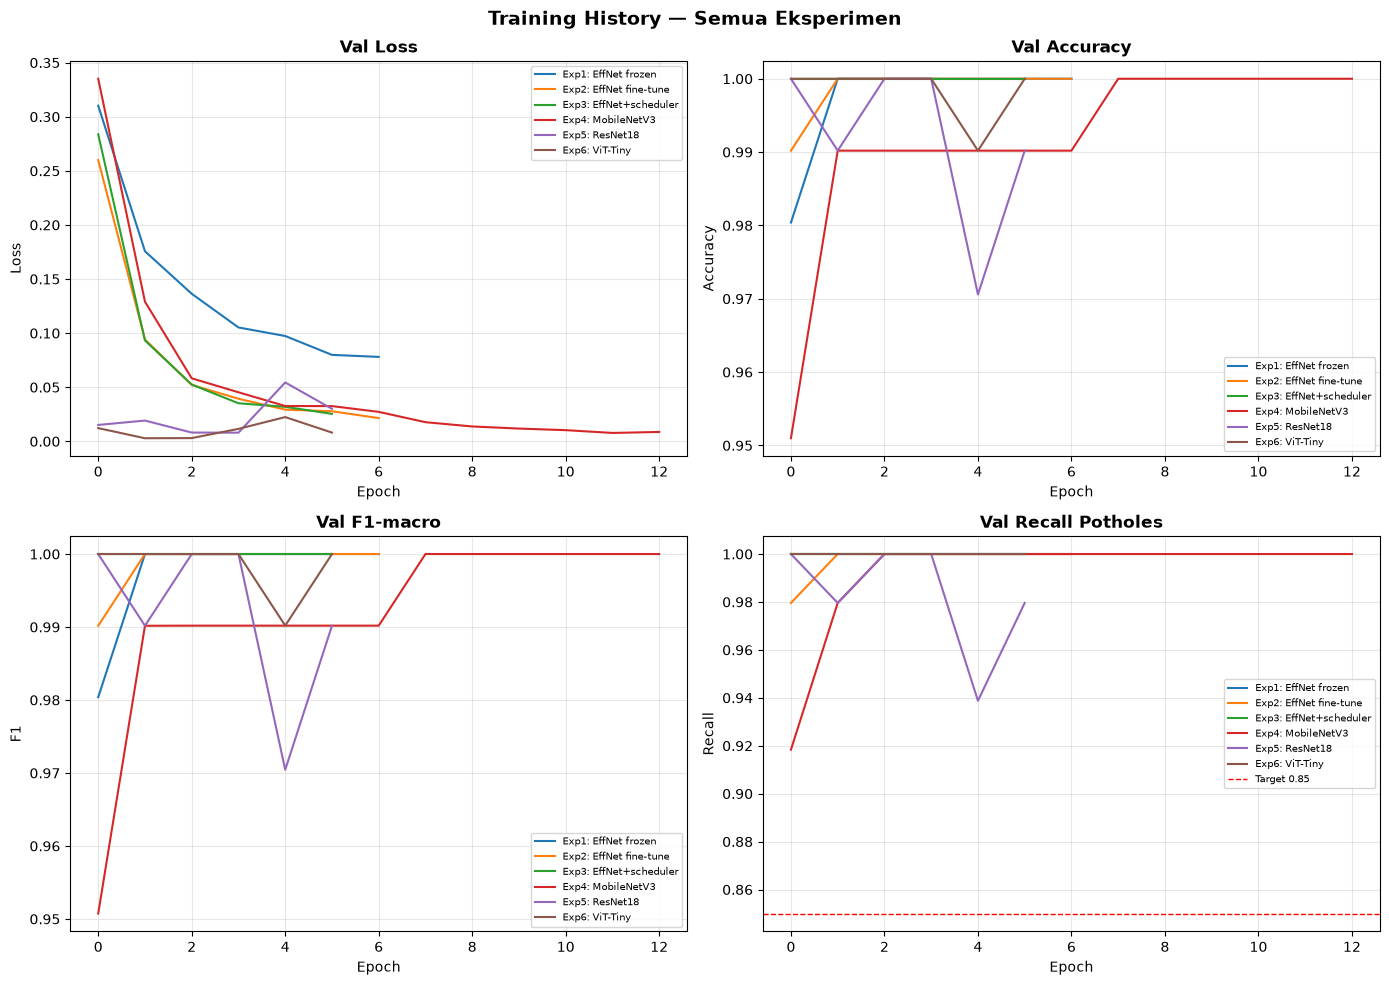

In [14]:
exp_keys = [k for k in experiments if experiments[k]["history"] is not None]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for exp_name in exp_keys:
    hist = experiments[exp_name]["history"]
    axes[0, 0].plot(hist["val_loss"],         label=exp_name)
    axes[0, 1].plot(hist["val_acc"],          label=exp_name)
    axes[1, 0].plot(hist["val_f1"],           label=exp_name)
    axes[1, 1].plot(hist["val_rec_potholes"], label=exp_name)

titles = ["Val Loss", "Val Accuracy", "Val F1-macro", "Val Recall Potholes"]
ylabels = ["Loss", "Accuracy", "F1", "Recall"]
for ax, title, ylabel in zip(axes.flatten(), titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Garis target recall potholes
axes[1, 1].axhline(0.85, color="red", linestyle="--", lw=1, label="Target 0.85")
axes[1, 1].legend(fontsize=7)

plt.suptitle("Training History — Semua Eksperimen", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "modeling_history.png", dpi=120, bbox_inches="tight")
plt.show()